# Генерация текстур

Код ниже очень напоминает код из прошлого урока -- ведь по сути мы делаем все то же самое. Нужно только добавить сравнение матриц Грама в лосс и их вычисление.

In [2]:
import tensorflow as tf
import IPython.display as display
import time
from tqdm import tqdm

# tf.enable_eager_execution()

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import time

In [4]:
#@title

def clip_0_1(image):
    """
    Мы хотим уметь отображать нашу полученную картинку, а для этого ее значения должны
    находится в промежутке от 0 до 1. Наш алгоритм оптимизации этого нигде не учитывает
    поэтому к полученному изображению мы будем применять "обрезку" по значению

    """
    return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

def load_img(path_to_img, max_dim=512):
    """
    Данная функция считывает изображение с диска и приводит его к такому размеру,
    чтобы бОльшая сторона была равна max_dim пикселей.

    Для считывания изображения воспользуемся функциями tensorflow.
    """
    img = tf.io.read_file(path_to_img) # считываени файла
    img = tf.image.decode_image(img, channels=3)  # декодинг
    img = tf.image.convert_image_dtype(img, tf.float32) # uint8 -> float32, 255 -> 1

    shape = img.numpy().shape[:-1]
    long_dim = max(shape)
    scale = max_dim / long_dim
    new_shape = tuple((np.array(shape) * scale).astype(np.int32))

    img = tf.image.resize(img, new_shape) # изменение размера
    img = img[tf.newaxis, :] # добавляем batch dimension
    return img

def imshow(image, title=None):
    """
    Функция для отрисовки изображения
    """
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)

    plt.imshow(image)
    if title:
        plt.title(title)

def get_vgg_layers_model(layer_names):
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    outputs = [vgg.get_layer(name).output for name in layer_names]
    model = tf.keras.Model([vgg.input], outputs)
    return model

In [5]:
url = 'https://happywall-img-gallery.imgix.net/2657/grey_pebble_simplicity_display.jpg'
image_path = tf.keras.utils.get_file('stones.jpg', url)

1866097/1866097 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(np.float32(0.9996431), (1, 170, 256, 3))

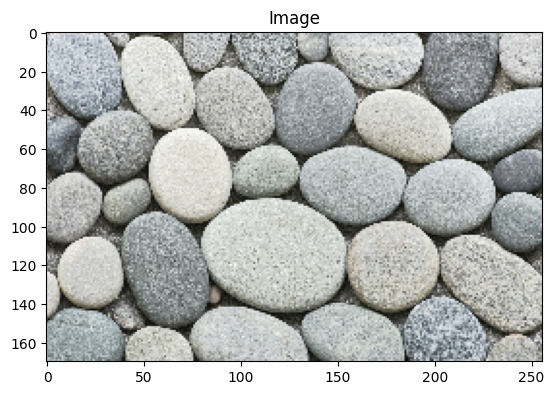

In [6]:
style_image = load_img(image_path, 256)
imshow(style_image, 'Image')
style_image.numpy().max(), style_image.numpy().shape # убедимся, что картинка нужного размера, а также значения
                                                         # лежат в промежутке от 0 до 1

# Матрица Грама
Матрица Грама для слоя $l$ считается по формуле:
$$G^l_{cd} = \frac{\sum_{ij} F^l_{ijc}(x)F^l_{ijd}(x)}{IJ}$$

Здесь дословно написано: то, что получится в матрице в позиции $c, d$ равно сумме произведений активаций канала $c$ и $d$, деленное на количество таких активаций.

Это можно записать с помощью функции ниже используя специальную нотацию.


In [7]:
def gram_matrix(input_tensor):
  result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
  input_shape = tf.shape(input_tensor)
  num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
  return result/(num_locations)

In [8]:
class StyleExtractor:
  def __init__(self, layers):
    self.vgg_outputs_model =  get_vgg_layers_model(layers)
    self.vgg_outputs_model.trainable = False
    self.style_layers = layers

  def __call__(self, inputs):
    """
    На входе 4х мерный тензор (картинка). Значения пикселей ограничены 0..1!

    На выходе: {"имя слоя": матрица грамма выхода этого слоя}
    """
    preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs*255.) # VGG препроцессинг
    outputs = self.vgg_outputs_model(preprocessed_input)
    # посчитаем матрицу грамма для каждого выхода
    style_outputs = [gram_matrix(style_output)
                        for style_output in outputs]

    # добавим выходы в словарь, где ключ -- имя слоя, а значение -- его матрица грамма
    features_dict = {name:value for name, value in zip(self.style_layers, style_outputs)}

    return features_dict

In [9]:
# выберем эти слои для сравнения матриц
style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv1']

extractor = StyleExtractor(style_layers)
style_targets = extractor(style_image)
for k, v in style_targets.items():
    print(f"{k}:{v.numpy().shape}")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
block1_conv1:(1, 64, 64)
block2_conv1:(1, 128, 128)
block3_conv1:(1, 256, 256)
block4_conv1:(1, 512, 512)
block5_conv1:(1, 512, 512)


#  Определение лосса

Для вычисления лосса нам нужно знать с чем сравнивать матрицы грамма активаций сети для сгенерированного изображения.

Мы можем их вычислить один раз для оригинального изображения и затем сравнивать с ними.

In [10]:
# Переменная style_targets -- содержит словарь в котором сохранены матрицы грамма промежуточных выходов сети примененной к оригинальной картинке
extractor = StyleExtractor(style_layers)
style_targets = extractor(style_image)

Определим лосс:

In [11]:
def loss(image):
    """
    Получаем картинку, вычисляем признаки с помощью класса StyleExtractor.
    Сравниваем их с style_targets с помощью MeanSquaredError.
    """
    current_features = extractor(image)
    loss = tf.add_n([tf.keras.losses.MeanSquaredError()(current_features[name], style_targets[name])
                                     for name in current_features.keys()])
    loss *= 1. / len(current_features)

    # для того чтобы результаты были больше похожи на настоящую картинку -- добавим регуляризацию
    # в реальных картинках цвета меняются плавно и нет цветового шума (шумные цветные пиксели поверх картинки)
    # при оптимизации мы часто будем получать такие результаты -- чтобы их уменьшать будуем штрафовать за такие резкие перепады цветов.
    # tota_variation -- нам в этом поможет
    loss += tf.image.total_variation(image)*1e4
    return loss

In [12]:
def train_step(image, loss_func, optimizer):
    """
    Шаг оптимизации мы реализуем вручную (без .fit()). Такая реализация будет
    нам полезна в дальнейшем.

    """

    with tf.GradientTape() as tape: # "записываем" градиенты для дальнейшего использования
        loss = loss_func(image)
    grad = tape.gradient(loss, image) # dLoss/dImage
    optimizer.apply_gradients([(grad, image)]) # шаг градиентного спуск. в случае  GD: image = image - lambda*dLoss/dImage
                                         # картинка после этого шага изменилась!
    image.assign(clip_0_1(image)) # ~ image = clip_0_1(image), "обрезаем" неправильные значения
    return loss.numpy()

In [13]:
def show_pair(original, generated, title=None):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    imshow(original, 'Original Image')
    plt.subplot(1, 2, 2)
    imshow(generated, title)

# Собираем все вместе

1866097/1866097 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


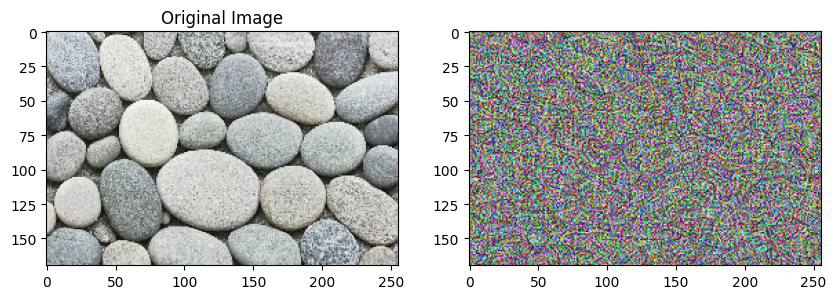

In [14]:
url = 'https://happywall-img-gallery.imgix.net/2657/grey_pebble_simplicity_display.jpg'
#url = "https://cdn.britannica.com/s:500x350/86/170586-120-7E23E561.jpg"
image_path = tf.keras.utils.get_file('pebble.jpg', url)
style_image = load_img(image_path, 256)
style_targets = extractor(style_image)

image = tf.Variable(np.random.rand(*style_image.numpy().shape).astype(np.float32))
opt = tf.keras.optimizers.Adam(learning_rate=0.05, beta_1=0.99, epsilon=1e-1)

# сделаем шаг оптимизации -- убедимся что все работает без ошибок.
train_step(image, loss_func=loss, optimizer=opt)
show_pair(style_image, image)

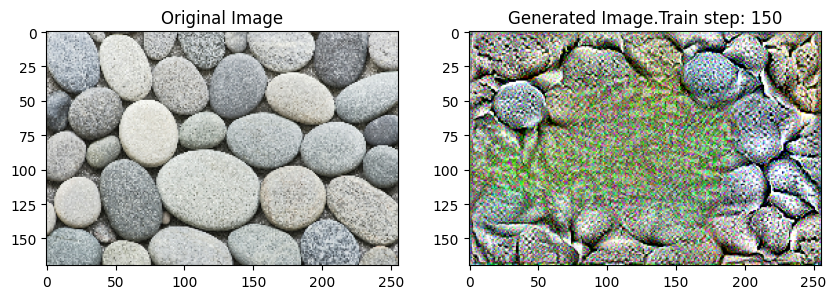

  4%|▍         | 2/50 [00:00<00:06,  7.24it/s]


KeyboardInterrupt: 

In [15]:
start = time.time()

epochs = 50
steps_per_epoch = 50

step = 0
for n in range(epochs):
  for m in tqdm(range(steps_per_epoch)):
    step += 1
    train_step(image, loss_func=loss, optimizer=opt)

  display.clear_output(wait=True)
  show_pair(style_image, image, f"Generated Image.Train step: {step}")
  plt.savefig(f"result_{step:5d}.png", bbox_inches='tight')
  plt.show()

end = time.time()
print("Total time: {:.1f}".format(end-start))
display.clear_output(wait=True)
show_pair(style_image, image, f"Generated Image")
plt.savefig(f"result.png", bbox_inches='tight')

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Пытаемся загрузить: /content/drive/MyDrive/дрова.PNG
 Файл существует!


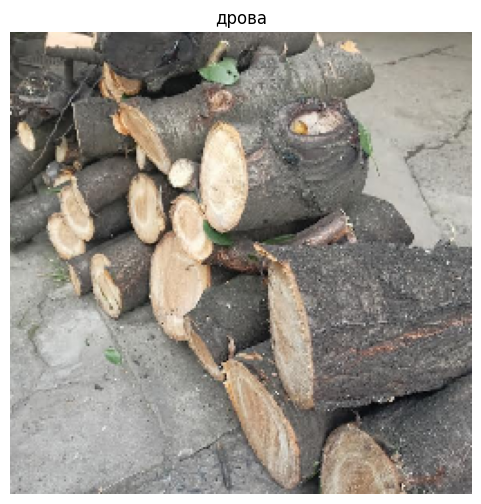


 Свойства:
Максимальное значение: 255
Размер: (256, 256, 3)

style_image.numpy().max(), style_image.numpy().shape
Результат: 255, (256, 256, 3)


In [46]:
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt
import numpy as np
import os


name_file = 'дрова'
# 1. ПРАВИЛЬНЫЙ путь с заглавными .PNG
image_path = f'/content/drive/MyDrive/{name_file}.PNG'  # ← .PNG с заглавными!

print(f"Пытаемся загрузить: {image_path}")

if os.path.exists(image_path):
    print(" Файл существует!")

    # 2. Загружаем
    style_image = load_img(image_path, target_size=(256, 256))

    # 3. Показываем
    plt.figure(figsize=(6, 6))
    plt.imshow(style_image)
    plt.title(f'{name_file}')
    plt.axis('off')
    plt.show()

    # 4. Проверяем
    img_array = np.array(style_image)
    print(f"\n Свойства:")
    print(f"Максимальное значение: {img_array.max()}")
    print(f"Размер: {img_array.shape}")

    #
    print(f"\nstyle_image.numpy().max(), style_image.numpy().shape")
    print(f"Результат: {img_array.max()}, {img_array.shape}")

else:
    print(" Файл не найден!")

    # Покажем, что реально есть в папке
    print("\nРеальные файлы в папке:")
    for f in os.listdir('/content/drive/MyDrive'):
        print(f"  - {f}")

In [47]:
# 1. Загрузите ваше изображение
from tensorflow.keras.preprocessing.image import load_img
import numpy as np
import tensorflow as tf

# Путь к вашему изображению
image_path = f'/content/drive/MyDrive/{name_file}.PNG'

# 2. Загружаем и преобразуем В ТЕНЗОР С BATCH DIMENSION
style_image_pil = load_img(image_path, target_size=(256, 256))
style_image_np = np.array(style_image_pil).astype(np.float32) / 255.0

# ВАЖНО: преобразуем в тензор и добавляем batch dimension
style_image_tensor = tf.convert_to_tensor(style_image_np)
style_image_tensor = tf.expand_dims(style_image_tensor, axis=0)  # Теперь (1, 256, 256, 3)

# 3. Проверяем
print(f" Загружено: {image_path}")
print(f"Размер numpy: {style_image_np.shape}")  # Для показа
print(f"Размер тензора: {style_image_tensor.shape}")  # Для модели
print(f"Диапазон: [{style_image_np.min():.3f}, {style_image_np.max():.3f}]")

 Загружено: /content/drive/MyDrive/дрова.PNG
Размер numpy: (256, 256, 3)
Размер тензора: (1, 256, 256, 3)
Диапазон: [0.000, 1.000]


In [39]:
# 4. Извлекаем стилевые признаки (extractor уже создан ранее)
style_targets = extractor(style_image_tensor)  # передаём тензор с batch dimension!

print("\n Стилевые признаки извлечены:")
for k, v in style_targets.items():
    print(f"{k}: {v.numpy().shape}")


 Стилевые признаки извлечены:
block1_conv1: (1, 64, 64)
block2_conv1: (1, 128, 128)
block3_conv1: (1, 256, 256)
block4_conv1: (1, 512, 512)
block5_conv1: (1, 512, 512)


In [48]:
# ===== ТОЛЬКО ЕСЛИ extractor не создан =====
extractor = StyleExtractor(style_layers)
style_targets = extractor(style_image_tensor)  # передаём тензор с batch dimension!

In [49]:
# ===== ИНИЦИАЛИЗАЦИЯ ГЕНЕРИРУЕМОГО ИЗОБРАЖЕНИЯ =====
# Должно быть такой же формы как style_image_tensor
image = tf.Variable(
    tf.random.uniform(style_image_tensor.shape, minval=0, maxval=1)
)

print(f"\n Генерируемое изображение создано:")
print(f"Размер: {image.shape}")


 Генерируемое изображение создано:
Размер: (1, 256, 256, 3)



 Тестовый шаг оптимизации...
 Тестовый шаг выполнен!


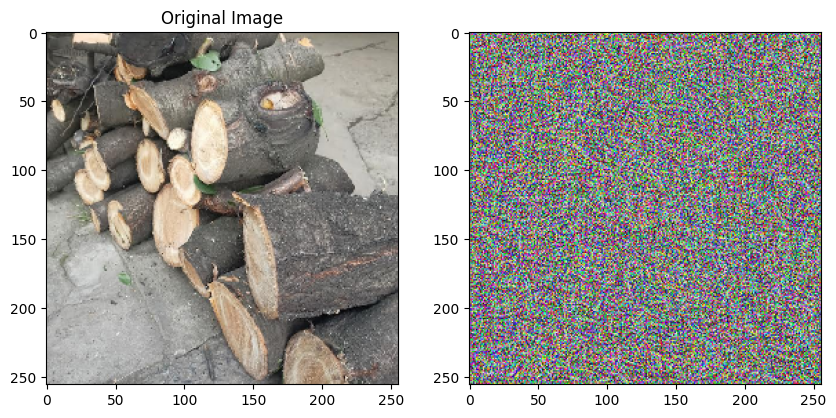

In [50]:
# ===== ТЕСТОВЫЙ ШАГ =====
# ЗАМЕНА СТАРОГО OPT НА ЭТОТ НОВЫЙ БЛОК:
initial_lr = 0.05
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_lr,
    decay_steps=1000,      # каждые 1000 шагов
    decay_rate=0.96,       # уменьшаем на 4%
    staircase=True
)

opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

print("\n Тестовый шаг оптимизации...")
train_step(image, loss_func=loss, optimizer=opt)
print(" Тестовый шаг выполнен!")

# Показываем
show_pair(style_image_np, image[0])  # image[0] - убираем batch dimension

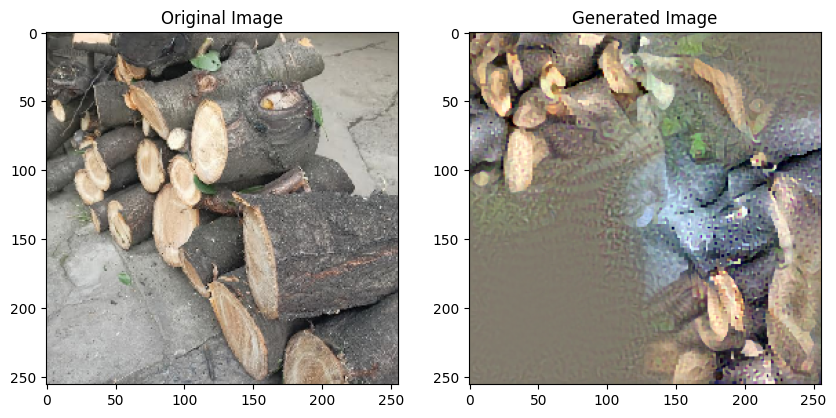

In [51]:
# ===== ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ =====
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython import display

start = time.time()

epochs = 100
steps_per_epoch = 50

step = 0
for n in range(epochs):
  for m in tqdm(range(steps_per_epoch)):
    step += 1
    train_step(image, loss_func=loss, optimizer=opt)

  display.clear_output(wait=True)
  show_pair(style_image_np, image[0], f"Generated Image. Train step: {step}")
  plt.savefig(f"result_{step:05d}.png", bbox_inches='tight')
  plt.show()

end = time.time()
print("Total time: {:.1f}".format(end-start))
display.clear_output(wait=True)
show_pair(style_image_np, image[0], f"Generated Image")
plt.savefig(f"result.png", bbox_inches='tight')

📊 Анализ 5 эпох обучения


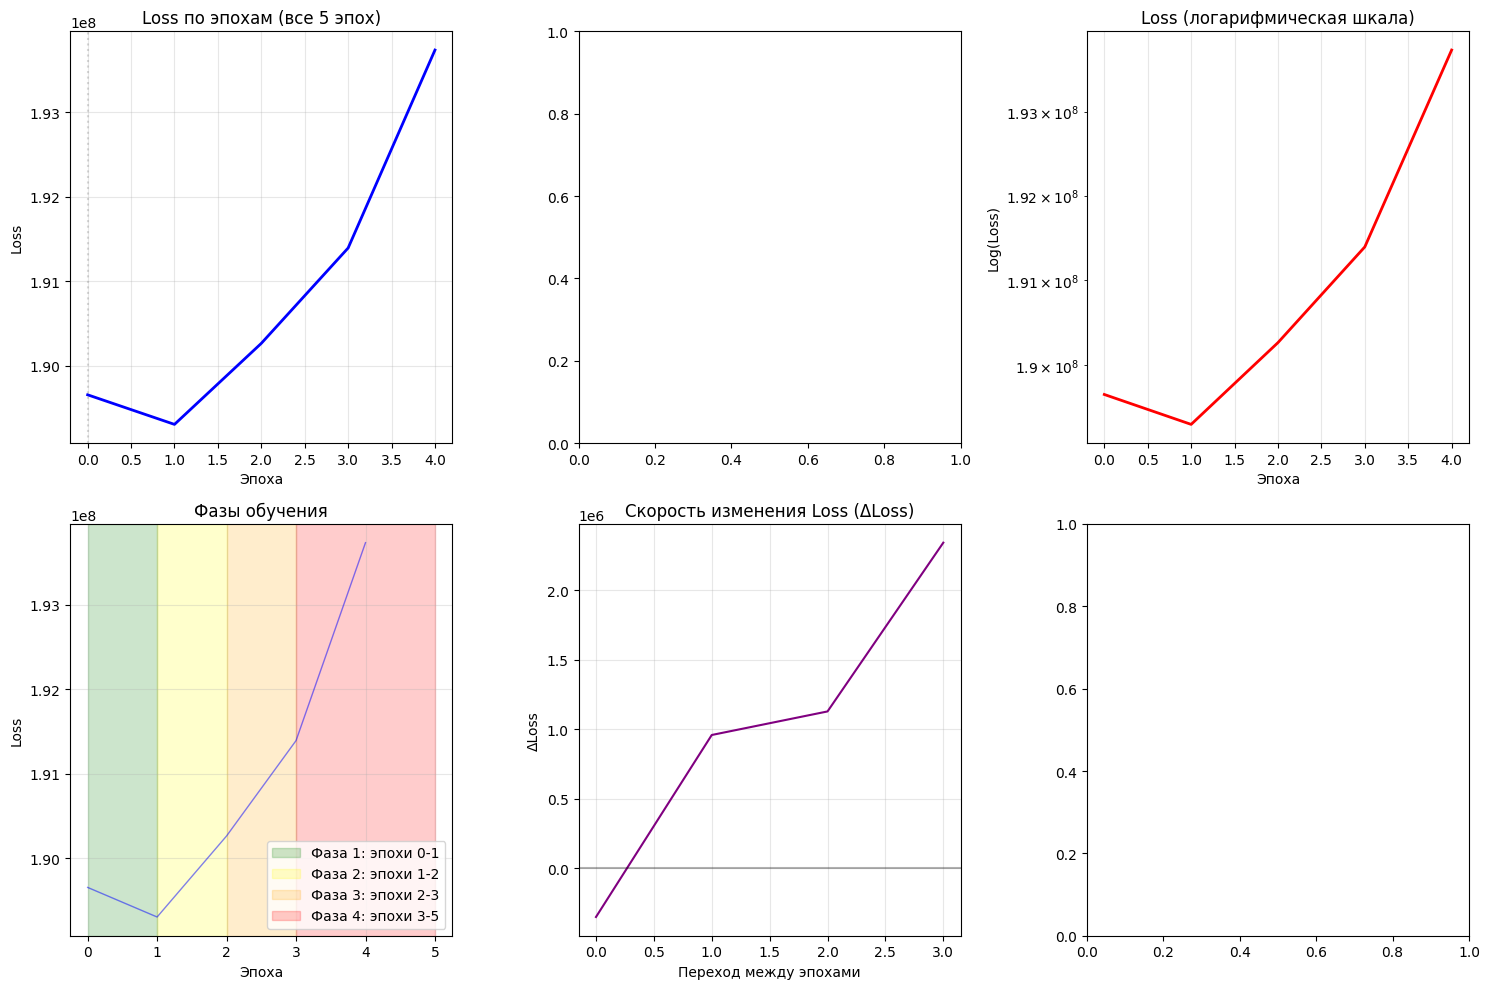


📈 СТАТИСТИКА ПО ДЕСЯТКАМ ЭПОХ:
--------------------------------------------------
Эпохи   0-  4: min=189307088.000000, max=193734208.000000, mean=190871424.000000, change=+4077200.000000


In [56]:
# УПРОЩЁННЫЙ АНАЛИЗ ДЛЯ 200 ЭПОХ
import numpy as np
import matplotlib.pyplot as plt

# Если у вас уже есть loss_history, используйте его
# Если нет - создайте тестовые данные как раньше

print(f"📊 Анализ {len(loss_history)} эпох обучения")

# 1. Основные графики на одной фигуре
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# График 1: Полный график loss
axes[0, 0].plot(loss_history, 'b-', linewidth=2)
axes[0, 0].set_title(f'Loss по эпохам (все {len(loss_history)} эпох)')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# Отметим каждую 20-ю эпоху для наглядности
for i in range(0, len(loss_history), 20):
    axes[0, 0].axvline(x=i, color='gray', linestyle=':', alpha=0.3)

# График 2: Loss последних 50 эпох (крупным планом)
if len(loss_history) >= 50:
    axes[0, 1].plot(range(len(loss_history)-50, len(loss_history)),
                    loss_history[-50:], 'g-', linewidth=2)
    axes[0, 1].set_title('Последние 50 эпох (крупный план)')
    axes[0, 1].set_xlabel('Эпоха')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)

# График 3: Логарифмическая шкала
axes[0, 2].semilogy(loss_history, 'r-', linewidth=2)
axes[0, 2].set_title('Loss (логарифмическая шкала)')
axes[0, 2].set_xlabel('Эпоха')
axes[0, 2].set_ylabel('Log(Loss)')
axes[0, 2].grid(True, alpha=0.3)

# График 4: Разбивка по фазам обучения
axes[1, 0].plot(loss_history, 'b-', linewidth=1, alpha=0.5)

# Раскрасим фазы
phases = 4
phase_len = len(loss_history) // phases
colors = ['green', 'yellow', 'orange', 'red']

for i in range(phases):
    start = i * phase_len
    end = (i + 1) * phase_len if i < phases - 1 else len(loss_history)
    axes[1, 0].axvspan(start, end, alpha=0.2, color=colors[i],
                      label=f'Фаза {i+1}: эпохи {start}-{end}')

axes[1, 0].set_title('Фазы обучения')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# График 5: Скорость сходимости (производная)
loss_diff = np.diff(loss_history)
axes[1, 1].plot(loss_diff, color='purple', linewidth=1.5)
axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1, 1].set_title('Скорость изменения Loss (ΔLoss)')
axes[1, 1].set_xlabel('Переход между эпохами')
axes[1, 1].set_ylabel('ΔLoss')
axes[1, 1].grid(True, alpha=0.3)

# График 6: Статистика по 20 частям
num_parts = min(20, len(loss_history) // 5)
if num_parts > 1:
    part_size = len(loss_history) // num_parts
    means = []
    stds = []
    part_labels = []

    for i in range(num_parts):
        start = i * part_size
        end = (i + 1) * part_size if i < num_parts - 1 else len(loss_history)
        part_data = loss_history[start:end]
        means.append(np.mean(part_data))
        stds.append(np.std(part_data))
        part_labels.append(f'{start}-{end}')

    x_pos = range(1, num_parts + 1)
    axes[1, 2].errorbar(x_pos, means, yerr=stds, fmt='o-', capsize=4)
    axes[1, 2].set_title(f'Loss по {num_parts} частям')
    axes[1, 2].set_xlabel('Интервал эпох')
    axes[1, 2].set_ylabel('Loss (mean ± std)')
    axes[1, 2].set_xticks(x_pos)
    axes[1, 2].set_xticklabels(part_labels, rotation=45, fontsize=8)
    axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 2. Подробная статистика по эпохам
print("\n📈 СТАТИСТИКА ПО ДЕСЯТКАМ ЭПОХ:")
print("-" * 50)

for decade in range(0, len(loss_history), 10):  # каждые 10 эпох
    end = min(decade + 10, len(loss_history))
    decade_losses = loss_history[decade:end]

    if len(decade_losses) > 0:
        print(f"Эпохи {decade:3d}-{end-1:3d}: "
              f"min={min(decade_losses):.6f}, "
              f"max={max(decade_losses):.6f}, "
              f"mean={np.mean(decade_losses):.6f}, "
              f"change={decade_losses[-1]-decade_losses[0]:+.6f}")

In [53]:
import imageio
from pathlib import Path
from PIL import Image as PILImage
import numpy as np

filenames = sorted(list(Path(".").glob("result_*.png")))

if filenames:
    images = []
    target_size = (256, 256)  # Размер, который ожидаем

    print(f"Обрабатываем {len(filenames)} кадров...")

    for i, filename in enumerate(filenames):
        try:
            # Открываем изображение
            img = PILImage.open(filename)

            # ПРОВЕРЯЕМ И ИСПРАВЛЯЕМ РАЗМЕР
            if img.size != target_size:
                print(f"  Кадр {i+1}: меняем размер {img.size} → {target_size}")
                img = img.resize(target_size, PILImage.Resampling.LANCZOS)

            # Преобразуем в numpy array
            img_array = np.array(img)

            # Проверяем каналы (RGB vs RGBA)
            if len(img_array.shape) == 3 and img_array.shape[2] == 4:
                # Если RGBA, конвертируем в RGB
                img = img.convert('RGB')
                img_array = np.array(img)

            images.append(img_array)

            if (i + 1) % 10 == 0 or i == 0:
                print(f"  Обработано {i+1}/{len(filenames)} кадров, размер: {img_array.shape}")

        except Exception as e:
            print(f"   Ошибка при обработке {filename}: {e}")
            continue

    if images:
        # Проверяем, что все изображения одного размера
        shapes = set([img.shape for img in images])
        print(f"\n Найденные размеры изображений: {shapes}")

        if len(shapes) > 1:
            print("  Разные размеры! Приводим к общему...")
            # Находим наиболее частый размер
            from collections import Counter
            shape_counts = Counter([img.shape for img in images])
            most_common_shape = shape_counts.most_common(1)[0][0]
            print(f"  Наиболее частый размер: {most_common_shape}")

            # Приводим все к одному размеру
            fixed_images = []
            for img in images:
                if img.shape != most_common_shape:
                    pil_img = PILImage.fromarray(img)
                    pil_img = pil_img.resize((most_common_shape[1], most_common_shape[0]))
                    img = np.array(pil_img)
                fixed_images.append(img)

            images = fixed_images

        # Сохраняем GIF
        print(f"\n🎬 Сохраняем GIF из {len(images)} кадров...")
        try:
            imageio.mimsave(
                f'{name_file}.gif',
                images,
                duration=0.1,  # 0.1 секунды на кадр
                fps=10,        # 10 кадров в секунду
                loop=0         # бесконечный цикл
            )

            print(f" GIF создан: {name_file}.gif")
            print(f"   Кадров: {len(images)}")
            print(f"   Размер кадра: {images[0].shape}")

        except Exception as e:
            print(f" Ошибка при сохранении GIF: {e}")
    else:
        print(" Не удалось обработать ни одного изображения")

else:
    print(" Файлы result_*.png не найдены")

Обрабатываем 200 кадров...
  Кадр 1: меняем размер (836, 418) → (256, 256)
  Обработано 1/200 кадров, размер: (256, 256, 3)
  Кадр 2: меняем размер (836, 418) → (256, 256)
  Кадр 3: меняем размер (836, 418) → (256, 256)
  Кадр 4: меняем размер (836, 418) → (256, 256)
  Кадр 5: меняем размер (836, 418) → (256, 256)
  Кадр 6: меняем размер (836, 418) → (256, 256)
  Кадр 7: меняем размер (836, 418) → (256, 256)
  Кадр 8: меняем размер (836, 418) → (256, 256)
  Кадр 9: меняем размер (836, 418) → (256, 256)
  Кадр 10: меняем размер (836, 418) → (256, 256)
  Обработано 10/200 кадров, размер: (256, 256, 3)
  Кадр 11: меняем размер (836, 418) → (256, 256)
  Кадр 12: меняем размер (836, 418) → (256, 256)
  Кадр 13: меняем размер (836, 418) → (256, 256)
  Кадр 14: меняем размер (836, 418) → (256, 256)
  Кадр 15: меняем размер (836, 418) → (256, 256)
  Кадр 16: меняем размер (836, 418) → (256, 256)
  Кадр 17: меняем размер (836, 418) → (256, 256)
  Кадр 18: меняем размер (836, 418) → (256, 256)
 

# Заключение

Мои поздравления. Мы научились генерировать текстуры! Решение поставленной нами задачи оказалось очень находчивым. Можно только удивляться как авторы статьи придумали такой подход к решению. Но еще более ошеломительные результаты показала следующая статья этих же авторов -- статья про перенос стиля. Как же они это сделали? Об этом мы узнаем в следующем уроке.

А сейчас предлагаю вам попрактиковаться -- выбрать 2-3 текстуры и попробовать сгенерировать новые из них. Для улучшения результата, попробуйте изменять параметры оптимизатора, степень регуляризации и тд.



## Практика

Выберите 2-3 текстуры и сгенерируйте из них новые. Попробуйте улучшить качество с помощью изменения параметров